## Step 1: Import Libraries

In [ ]:
import os
import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, log_loss

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

In [ ]:

!pip install kaggle
from google.colab import userdata
import os

os.environ['KAGGLE_USERNAME'] = 'synapticpush'
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_TOKEN')

In [ ]:

!kaggle datasets download -d minahilfatima12328/consumer-shopping-trends-analysis
!unzip consumer-shopping-trends-analysis.zip

Dataset URL: https://www.kaggle.com/datasets/minahilfatima12328/consumer-shopping-trends-analysis
License(s): CC0-1.0
consumer-shopping-trends-analysis.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  consumer-shopping-trends-analysis.zip
replace Consumer_Shopping_Trends_2026 (6).csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## Step 2: Load Dataset

In [ ]:
data_path = r'/content/Consumer_Shopping_Trends_2026 (6).csv'
df = pd.read_csv(data_path)

print('Dataset shape:', df.shape)
display(df.head())

target_column = 'shopping_preference'
print(df[target_column].value_counts())

Dataset shape: (11789, 25)


,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,avg_store_spend,discount_sensitivity,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,144092,2,3,2,6,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,28421,4,7,4,1,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,128229,9,4,5,3,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,134650,7,0,3,3,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,34122,5,9,2,4,2,5,8,9,7,1,6,Male,Tier 3,Store


shopping_preference
Store     10244
Online     1176
Hybrid      369
Name: count, dtype: int64


In [ ]:
# Update the data_path to point to the downloaded CSV file
data_path = 'Consumer_Shopping_Trends_2026 (6).csv'

df = pd.read_csv(data_path)

print('Dataset shape:', df.shape)
display(df.head())

target_column = 'shopping_preference'
print(df[target_column].value_counts())

Dataset shape: (11789, 25)


,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,avg_store_spend,discount_sensitivity,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,144092,2,3,2,6,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,28421,4,7,4,1,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,128229,9,4,5,3,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,134650,7,0,3,3,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,34122,5,9,2,4,2,5,8,9,7,1,6,Male,Tier 3,Store


shopping_preference
Store     10244
Online     1176
Hybrid      369
Name: count, dtype: int64


## Step 3: Prepare Data

In [ ]:
X = df.drop(columns=[target_column])
y_text = df[target_column]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

X = pd.get_dummies(X, drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=3,
    stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Classes:', list(label_encoder.classes_))

X_train shape: (9431, 28)
X_test shape: (2358, 28)
Classes: ['Hybrid', 'Online', 'Store']


## Step 4: Train Logistic Regression Model

In [ ]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

print('Model training completed')

Model training completed


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Step 5: Check Model Performance

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
loss = log_loss(y_test, y_prob)

print('Accuracy:', round(accuracy, 4))
print('Weighted F1 Score:', round(f1, 4))
print('Log Loss:', round(loss, 4))

pred_labels = label_encoder.inverse_transform(y_pred)
true_labels = label_encoder.inverse_transform(y_test)

print('\nClassification Report:\n')
print(classification_report(true_labels, pred_labels))

Accuracy: 0.9843
Weighted F1 Score: 0.9845
Log Loss: 0.0352

Classification Report:

              precision    recall  f1-score   support

      Hybrid       0.73      0.78      0.76        74
      Online       0.96      0.95      0.96       235
       Store       1.00      1.00      1.00      2049

    accuracy                           0.98      2358
   macro avg       0.90      0.91      0.90      2358
weighted avg       0.98      0.98      0.98      2358



## Step 6: Plot Confusion Matrix

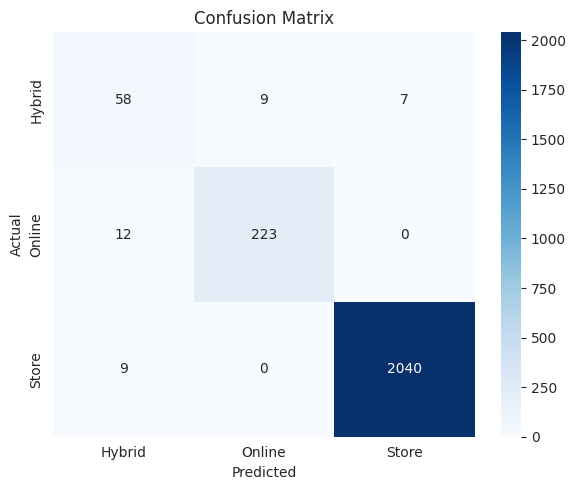

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 7: Save Final Predictions

In [ ]:
results = pd.DataFrame({
    'Actual': true_labels,
    'Predicted': pred_labels
})

display(results.head(15))

base_output = r'd:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\Consumer_Shopping_Trends'
model_dir = os.path.join(base_output, 'model')
metrics_dir = os.path.join(base_output, 'metrics')

os.makedirs(model_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

save_path = os.path.join(metrics_dir, 'prediction.csv')
results.to_csv(save_path, index=False)
print('Saved file:', save_path)

,Actual,Predicted
0,Store,Store
1,Store,Store
2,Store,Store
3,Store,Store
4,Store,Store
5,Store,Store
6,Store,Store
7,Store,Store
8,Store,Store
9,Store,Store


Saved file: d:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\Consumer_Shopping_Trends/metrics/prediction.csv


## Step 8: Final Summary

In [ ]:
summary = pd.DataFrame([
    {'Metric': 'Accuracy', 'Value': accuracy},
    {'Metric': 'Weighted F1', 'Value': f1},
    {'Metric': 'Log Loss', 'Value': loss}
])

display(summary)
print('Target classes:', list(label_encoder.classes_))

base_output = r'd:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\Consumer_Shopping_Trends'
model_dir = os.path.join(base_output, 'model')
metrics_dir = os.path.join(base_output, 'metrics')

os.makedirs(model_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'model.joblib')
columns_path = os.path.join(model_dir, 'feature_columns.json')
labels_path = os.path.join(model_dir, 'label_classes.json')
info_path = os.path.join(model_dir, 'target_info.json')
metrics_path = os.path.join(metrics_dir, 'final_metircs.csv')

joblib.dump(model, model_path)
with open(columns_path, 'w', encoding='utf-8') as f:
    json.dump(list(X.columns), f, indent=2)
with open(labels_path, 'w', encoding='utf-8') as f:
    json.dump(list(label_encoder.classes_), f, indent=2)
with open(info_path, 'w', encoding='utf-8') as f:
    json.dump({'target_col': target_column, 'model_name': 'LogisticRegression'}, f, indent=2)
summary.to_csv(metrics_path, index=False)

print('Saved model:', model_path)
print('Saved columns:', columns_path)
print('Saved labels:', labels_path)
print('Saved target info:', info_path)
print('Saved metrics:', metrics_path)

,Metric,Value
0,Accuracy,0.984309
1,Weighted F1,0.984535
2,Log Loss,0.035234


Target classes: ['Hybrid', 'Online', 'Store']
Saved model: d:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\Consumer_Shopping_Trends/model/model.joblib
Saved columns: d:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\Consumer_Shopping_Trends/model/feature_columns.json
Saved labels: d:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\Consumer_Shopping_Trends/model/label_classes.json
Saved target info: d:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\Consumer_Shopping_Trends/model/target_info.json
Saved metrics: d:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\Consumer_Shopping_Trends/metrics/final_metircs.csv
